# 👀👂👄 Problem 1: Semantic Segmentaion
In this part, you will design and implement your Convolutional Neural Networks to perform semantic segmentation on the Mini CelebA Mask Dataset.

In [ ]:
!pip install colormap easydev pypng

In [ ]:
# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
dataset_root_path = kagglehub.dataset_download("chengyenchrisyang/mini-celeba")

print("Path to dataset files:", dataset_root_path)

In [ ]:
# make sure you see two folders: mini-CelebA-HQ-img &  mini-CelebAMask-HQ-mask-anno

!ls $dataset_root_path


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset

import torchvision
from torchvision import datasets, models, transforms

from PIL import Image
from sklearn.metrics import average_precision_score as ap_score
from torchsummary import summary
from tqdm import tqdm

from colormap.colors import Color, hex2rgb

In [ ]:
# make sure you are running on GPU!

if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    raise Exception("WARNING: Could not find GPU! Using CPU only. \
To enable GPU, please to go Edit > Notebook Settings > Hardware \
Accelerator and select GPU.")

## Dataset
We will create a custom Dataset function for the Mini CelebA dataset. You don't have to change anything here.

In [ ]:
color_to_label_mapping = {
    (0, 0, 0): 0,       # background
    (172, 219, 255): 1, # skin
    (0, 255, 0): 2,     # ???
    (255, 0, 0): 3,     # ???
    (0, 0, 255): 4,     # ???
    (255, 255, 0): 5,   # ???
    (0, 255, 255): 6,   # ???
    (255, 0, 255): 7,   # ???
}

label_to_color_mapping = {
    0: (0, 0, 0),
    1: (172, 219, 255),
    2: (0, 255, 0),
    3: (255, 0, 0),
    4: (0, 0, 255),
    5: (255, 255, 0),
    6: (0, 255, 255),
    7: (255, 0, 255),
}


class MiniCelebADataset(Dataset):
    # def __init__(self, flag, data_root='/kaggle/input/mini-celeba/', data_range=(0, 800), n_class=8, onehot=False):
    def __init__(self, flag, data_root=dataset_root_path, data_range=(0, 800), n_class=8, onehot=False):
        self.onehot = onehot
        self.n_class = n_class

        self.dataset = []
        for i in range(data_range[0], data_range[1]):
            img = cv2.imread(os.path.join(data_root, 'mini-CelebA-HQ-img', '%05d.png' % i))
            label = cv2.imread(os.path.join(data_root, 'mini-CelebAMask-HQ-mask-anno', '%05d.png' % i))


            # Normalize input image
            img = np.asarray(img).astype("f").transpose(2, 0, 1) / 128.0 - 1.0

            # Convert to n_class-dimensional onehot matrix
            label_ = np.asarray(label)


            # Create the one-hot encoded label
            one_hot_label = np.zeros((self.n_class, img.shape[1], img.shape[2])).astype("i")
            for j in range(self.n_class):
                # Match RGB values from the label image to the color_to_label_mapping
                # This assumes label_ is a (H, W, 3) numpy array
                color = label_to_color_mapping[j]
                # Check if the current pixel's color matches the color for class j
                match = np.all(label_ == color, axis=-1)
                one_hot_label[j, :, :] = match
            self.dataset.append((img, one_hot_label))

        print("load dataset done")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        img, label = self.dataset[index]
        label = torch.FloatTensor(label)
        if not self.onehot:
            label = torch.argmax(label, dim=0)
        else:
            label = label.long()

        return torch.FloatTensor(img), torch.LongTensor(label)

In [ ]:
train_data = MiniCelebADataset(flag='train', data_range=(0,1500), onehot=False)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_data = MiniCelebADataset(flag='train', data_range=(1500,1800), onehot=False)
val_loader = DataLoader(val_data, batch_size=16, shuffle=True)
test_data = MiniCelebADataset(flag='test', data_range=(1800,2000), onehot=False)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

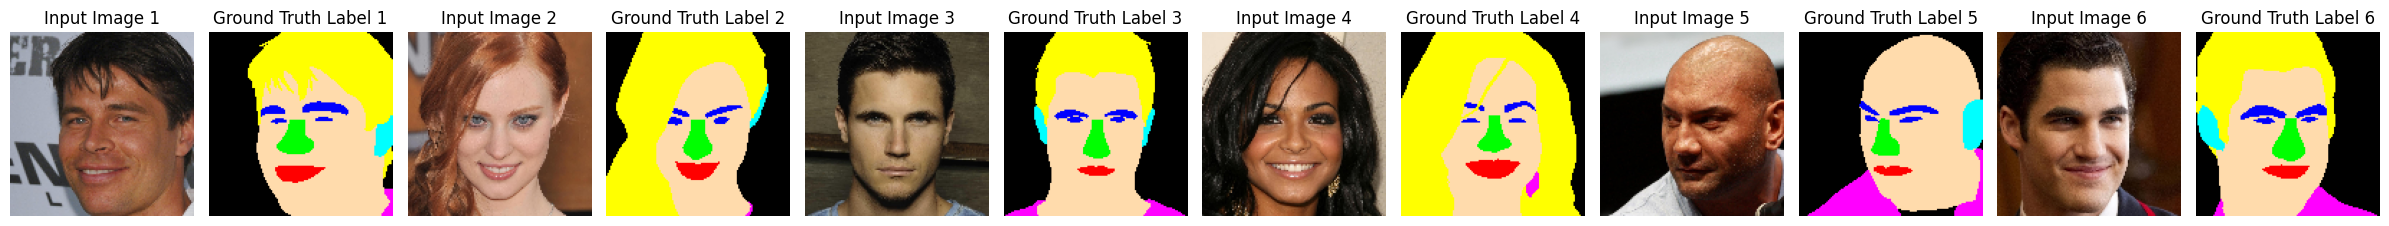

In [ ]:
# Get a batch of data from the train_loader
images, labels = next(iter(train_loader))

# Move data to CPU for visualization
images = images.cpu()
labels = labels.cpu()

num_to_visualize = 6

# Adjust figure size for side-by-side plots
plt.figure(figsize=(4 * num_to_visualize, 3))

for k in range(num_to_visualize):
    img_to_visualize = images[k]
    label_to_visualize = labels[k]

    # Denormalize the image for visualization
    img_to_visualize = (img_to_visualize + 1.0) * 128.0
    img_to_visualize = img_to_visualize.permute(1, 2, 0).numpy().astype(np.uint8)

    # Get the predicted color for each pixel based on the label index
    predicted_color_label = np.zeros((label_to_visualize.shape[0], label_to_visualize.shape[1], 3), dtype=np.uint8)
    for i in range(label_to_visualize.shape[0]):
        for j in range(label_to_visualize.shape[1]):
            class_idx = label_to_visualize[i, j].item()
            predicted_color_label[i, j] = label_to_color_mapping[class_idx]

    # Plot the original image and the ground truth label side-by-side for each item
    plt.subplot(1, num_to_visualize * 2, 2 * k + 1)
    plt.imshow(cv2.cvtColor(img_to_visualize, cv2.COLOR_BGR2RGB))
    plt.title(f'Input Image {k+1}')
    plt.axis('off')

    plt.subplot(1, num_to_visualize * 2, 2 * k + 2)
    plt.imshow(cv2.cvtColor(predicted_color_label, cv2.COLOR_BGR2RGB))
    plt.title(f'Ground Truth Label {k+1}')
    plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

1-(a) [5%] Based on your understanding of human facial features and semantic segmentation, provide a reasonable guess for each of the unknown labels (class 2--7). For each, write what you think the label represents (e.g., left eye, nose, mouth, etc.). Use any visualizations provided or inspection of the dataset to support your reasoning.

In [ ]:
# any code to help you reason your 1-(a) answers

1-(b) [5%] Please follow the code and finish training your baseline model \texttt{(take roughly 10 minutes to train)}. Report the training, validation, and learning rate curves in your report.

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()  # Changed from Net to UNet
        self.n_class = 8

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Center (Bottleneck)
        self.center = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        # Decoder
        # The input channels to the first decoder block will be the channels from
        # the center block plus the channels from the skip connection (128 + 128 = 256)
        self.dec1 = nn.Sequential(
            nn.Conv2d(256, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upsample1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # The input channels to the second decoder block will be the channels from
        # the previous decoder block plus the channels from the skip connection (64 + 64 = 128)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upsample2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Output layer
        self.out_conv = nn.Conv2d(64, self.n_class, 1, padding=0)


    def forward(self, x):
        # Encoder
        enc1_out = self.enc1(x)
        pool1_out = self.pool1(enc1_out)

        enc2_out = self.enc2(pool1_out)
        pool2_out = self.pool2(enc2_out)

        # Center
        center_out = self.center(pool2_out)

        # Decoder with skip connections
        upsample1_out = self.upsample1(center_out)
        # Concatenate skip connection from enc2_out
        concat1 = torch.cat([upsample1_out, enc2_out], dim=1)
        dec1_out = self.dec1(concat1)

        upsample2_out = self.upsample2(dec1_out)
        # Concatenate skip connection from enc1_out
        concat2 = torch.cat([upsample2_out, enc1_out], dim=1)
        dec2_out = self.dec2(concat2)

        # Output layer
        out = self.out_conv(dec2_out)

        return out

Ininitialize your model and look at the structure of your model, [torchsummary](https://github.com/sksq96/pytorch-summary) is a useful library to look at the computation graph of your model.

In [ ]:
name = 'starter_net'
net = UNet().to(device)
# visualizing the model
summary(net, (3,128,128))

Once you have completed the model implementation in the cell above, run the cell below to load helper functions and train the model.

In [ ]:
def train(trainloader, model, criterion, optimizer, scheduler, device, epoch):
    '''
    Helper function for training.
    '''
    start = time.time()
    running_loss = 0.0
    cnt = 0

    model.train()

    # Loop through batches from the data loader
    for images, labels in tqdm(trainloader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # Clear previous gradients
        output = model(images) # Forward pass
        loss = criterion(output, labels) # Calculate loss
        loss.backward() # Backward pass (compute gradients)
        optimizer.step() # Update model weights

        running_loss += loss.item() # Accumulate batch loss
        cnt += 1 # Increment batch counter

    end = time.time()

    running_loss /= cnt

    print('[epoch %d] training loss: %.3f | learning rate: %.5f | elapsed time %.3f' % (epoch, running_loss, optimizer.param_groups[0]['lr'], end-start))

    scheduler.step() # Update the learning rate according to the scheduler

    return running_loss


def test(testloader, model, criterion, device, epoch):
    '''
    Function for testing.
    '''
    start = time.time()
    running_loss = 0.0
    cnt = 0

    # Set the model to evaluation mode. This is crucial for layers like Dropout and BatchNorm.
    # Also, disable gradient calculation during evaluation to save memory and speed up.
    model.eval()
    with torch.no_grad():
        # Loop through batches from the data loader
        for images, labels in tqdm(testloader):
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)

            loss = criterion(output, labels)

            running_loss += loss.item()
            cnt += 1 #

    end = time.time() #

    running_loss /= cnt

    print('[epoch %d] validation loss: %.3f | elapsed time %.3f' % (epoch, running_loss, end-start))

    return running_loss # Return the average loss for the dataset

Experiment with with different optimizers, parameters (such as learning rate) and number of epochs. We expect you to achieve **0.45 AP** on the test set

In [ ]:
from torch.optim.lr_scheduler import LinearLR, ExponentialLR, CosineAnnealingLR, SequentialLR

model = UNet().to(device) # reinit the model just in case

num_epoch = 20
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=1e-5)

scheduler = ExponentialLR(optimizer, gamma=0.9)


trn_hist = []
val_hist = []
lr_hist = []
for epoch in range(num_epoch):
    print('================================Epoch %02d================================' % (epoch+1))
    trn_loss = train(train_loader, model, criterion, optimizer, scheduler, device, epoch+1)
    lr_hist.append(optimizer.param_groups[0]['lr'])

    val_loss = test(val_loader, model, criterion, device, epoch+1)
    trn_hist.append(trn_loss)
    val_hist.append(val_loss)

In [ ]:
def plot_hist(trn_hist, val_hist):
    x = np.arange(1, len(trn_hist)+1)
    plt.figure()
    # Plot training history in green
    plt.plot(x, trn_hist, color='green')
    # Plot validation history in red
    plt.plot(x, val_hist, color='red')
    plt.legend(['Training', 'Validation'])
    plt.xticks(x)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

plot_hist(trn_hist, val_hist)

In [ ]:
def plot_lr(lr_hist):
    x = np.arange(1, len(lr_hist)+1)
    plt.figure()
    plt.plot(x, lr_hist)
    plt.xticks(x)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')

plot_lr(lr_hist)

1-(c) [2.5%] Report the average precision on the test set and your observations. The function cal AP will calculate the average precision on the test set. All hyperparameter tuning should be done on the validation set. We expect you to achieve over 0.6 AP on the test set with the baseline code.

In [ ]:
def save_label(label, path):
  '''
  Function for plotting labels for the Mini CelebA Mask dataset (8 classes).
  Saves a color image using cv2.
  '''
  # Define the colormap based on your label_to_color_mapping in BGR format for cv2
  label_to_color_mapping_bgr = {
      0: (0, 0, 0),        # 0: background (BGR)
      1: (255, 219, 172),  # 1: skin (BGR - swapped from RGB)
      2: (0, 255, 0),      # 2:
      3: (0, 0, 255),      # 3:
      4: (255, 0, 0),      # 4: left_eye (BGR - swapped from RGB)
      5: (0, 255, 255),    # 5: right_eye (BGR - same as RGB)
      6: (255, 255, 0),    # 6: nose (BGR - swapped from RGB)
      7: (255, 0, 255),    # 7: mouth (BGR - same as RGB)
  }

  # Ensure the label is an integer type
  label = label.astype(np.uint8)

  # Create an empty color image
  height, width = label.shape
  color_label = np.zeros((height, width, 3), dtype=np.uint8)

  # Map the label indices to colors
  for i in range(height):
    for j in range(width):
      class_idx = label[i, j]
      color_label[i, j] = label_to_color_mapping_bgr[class_idx]

  # Save the color image using cv2.imwrite
  cv2.imwrite(path, cv2.cvtColor(color_label, cv2.COLOR_BGR2RGB))


def get_result(testloader, net, device, folder='output_train'):
  """
  Generates and saves segmentation results (input image, ground truth, prediction).
  Assumes a save_label(label, path) function is available.
  """
  os.makedirs(folder, exist_ok=True)

  with torch.no_grad():
    net = net.eval()
    cnt = 0
    for images, labels in tqdm(testloader, desc=f"Saving results to {folder}"):
      images = images.to(device)
      labels = labels.to(device)

      # Get model output
      output = net(images) # output shape: (batch_size, n_class, H, W)

      # Process each image in the batch
      for batch_idx in range(images.size(0)):
          # Get prediction for the current image
          pred = torch.argmax(output[batch_idx], dim=0).cpu().numpy().astype('uint8')

          # Get ground truth for the current image
          # Ensure labels are in the correct format (class indices)
          # If your labels are already class indices from the loader, this is fine.
          # If they are one-hot, you might need torch.argmax(labels[batch_idx], dim=0)
          gt = labels[batch_idx].cpu().numpy().astype('uint8')


          # Get the input image for the current item
          input_img = images[batch_idx].cpu().data.numpy()
          # Denormalize and transpose for saving
          input_img = ((input_img + 1.0) * 128).astype(np.uint8).transpose(1, 2, 0)

          # Save the prediction, ground truth, and input image
          save_label(pred, os.path.join(folder, f'y{cnt:05d}.png'))  # Predicted segmentation
          save_label(gt, os.path.join(folder, f'gt{cnt:05d}.png'))    # Ground truth segmentation

          # Save the input image using cv2 (more reliable for color images)
          # cv2.imwrite expects BGR, so convert from RGB
          plt_img_rgb = input_img
          cv2.imwrite(os.path.join(folder, f'x{cnt:05d}.png'), plt_img_rgb)

          cnt += 1

  print(f"Results saved to {folder}")

In [ ]:
def cal_AP(testloader, net, criterion, device):
  '''
  Calculate Average Precision
  '''
  # Removed unused losses and cnt
  with torch.no_grad():
    net = net.eval()
    preds = [[] for _ in range(8)]
    heatmaps = [[] for _ in range(8)]
    for images, labels in tqdm(testloader):
      images = images.to(device)
      labels = labels.to(device)
      output = net(images).cpu().numpy() # Model output are raw scores/logits

      # Ensure labels are on CPU and convert to numpy
      labels_np = labels.cpu().numpy()

      for c in range(8):
        # Reshape model output for class c
        preds[c].append(output[:, c].reshape(-1))

        # Create binary mask for class c from integer labels
        binary_mask_c = (labels_np == c).astype(np.int64) # Convert to int (0 or 1)
        heatmaps[c].append(binary_mask_c.reshape(-1))

    aps = []
    for c in range(8):
      preds[c] = np.concatenate(preds[c])
      heatmaps[c] = np.concatenate(heatmaps[c])

      if heatmaps[c].max() == 0:
        ap = float('nan') # This handles classes with no ground truth pixels
      else:
        ap = ap_score(heatmaps[c], preds[c])
        aps.append(ap)
      print(f"AP for class {c}: {ap}") # More informative print

    # Calculate mean AP only over classes that appeared
    mean_ap = np.nanmean(aps) # Use nanmean to ignore nans
    print(f"Average Precision (over appearing classes) = {mean_ap}")

  return mean_ap # Optionally return the mean AP

##########################################################################
# TODO: Submit the "Average Precision(all classes)" value in the report  #
##########################################################################
print('\nFinished Training, Testing on test set')
test(test_loader, model, criterion, device, epoch+1)
print('\nGenerating Unlabeled Result')
##############################################################################
# You can visualize your segmentation results using get_results function     #
# Your result will be dumped in the folder 'output_test'.                    #
# There will be three files for each image:                                  #
#   (1) gt<num>.png (ground truth label)                                     #
#   (2) x<num>.png (input RGB image)                                         #
#   (3) y<num>.png (predicted output)                                        #
#                                                                            #
# TODO: Find a satisfactory result by running the next cell and report       #
#       the plot of gt<num>.png, x<num>.png and y<num>.png in the pdf        #
# Note: Your submission doesn't have to be perfect.                          #
##############################################################################
result = get_result(test_loader, model, device, folder='output_test')

os.makedirs('./models', exist_ok=True)
torch.save(model.state_dict(), './models/model_{}.pth'.format(name))

cal_AP(test_loader, model, criterion, device)

1-(d) [2.5%] Find a satisfactory result in the output test folder generated by the get result function and paste it in your pdf. There should be three images for each input - $gt<num>.png$ (ground truth label), $x<num>.png$ (input RGB image) and $y<num>.png$ (predicted label).

In [ ]:
########################################################################
# TODO: Find a satisfactory result from the 200 test images            #
#       Submit the result in the pdf                                   #
# Note: Your submission doesn't have to be perfect.                    #
########################################################################
img_idx = 199
########################################################################
#                             END OF YOUR CODE                         #
########################################################################
output_dir = 'output_test'

plt.subplot(1, 3, 1)
plt.imshow(Image.open(os.path.join(output_dir, 'x{:05d}.png'.format(img_idx))))
plt.title('Input Image', fontsize=16)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Image.open(os.path.join(output_dir, 'gt{:05d}.png'.format(img_idx))))
plt.title('Ground Truth Segmentation Map', fontsize=16)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Image.open(os.path.join(output_dir, 'y{:05d}.png'.format(img_idx))))
plt.title('Predicted Segmentation Map', fontsize=16)
plt.axis('off')

plt.gcf().set_size_inches(18, 10)
plt.show()

1-(e) [10\%] Now try to improve the AP on the test set.
You are encouraged to try one or more of the following strategies:


*   Change the initial learning rate or number of training epochs \textbf{(easy)}
*   Try a different learning rate scheduler such as \texttt{ExponentialLR}, or warmup scheduling \textbf{(medium; bonus points)}
*  Design or modify a different model architecture beyond the basic U-Net \textbf{(hard; more bonus points)}


Please show your changes and observations of your new model on the test set, your bonus credit will be proportional to the difficulty and effectiveness of your enhancements.

In [ ]:
# you can reuse codes or turn in a copy of this python notebook for your implementations

1-(f) [2.5%] Why do you think skip connections are helpful in U-Net-like architectures for semantic segmentation tasks? Your answer may reference spatial resolution, gradient flow, or other relevant factors.

1-(g) [2.5%] What challenges arise when training a segmentation model using a dataset with imbalanced class distributions (e.g., small objects like eyes vs. large regions like skin)? Suggest one way to address this problem in training.

In [ ]:
# answer in your report (pdf)